# Preprocessing

## Extracting Cropped Trees from YOLO Boxes

Rows 17 to 28

EXTRACTING TREES - YAML MAPPING WITH POLYGON SUPPORT
Loaded 654 classes from YAML
Processing 654 annotations

Extraction complete!
  Extracted: 623 trees
  H0 skipped: 31

YOUR 5 LISTS HAVE BEEN CREATED

LIST 1 - HEALTH SCORE 1
   Variable: health_1
   Count: 8 trees
   First 5 trees:
     [0] R19_T20 - 28x25px
     [1] R20_T26 - 32x19px
     [2] R22_T18 - 33x28px
     [3] R23_T9 - 38x27px
     [4] R24_T12 - 35x24px

LIST 2 - HEALTH SCORE 2
   Variable: health_2
   Count: 52 trees
   First 5 trees:
     [0] R25_T4 - 68x37px
     [1] R17_T20 - 33x31px
     [2] R22_T53 - 38x31px
     [3] R24_T46 - 61x38px
     [4] R24_T35 - 40x38px

LIST 3 - HEALTH SCORE 3
   Variable: health_3
   Count: 339 trees
   First 5 trees:
     [0] R21_T48 - 68x69px
     [1] R22_T49 - 68x68px
     [2] R26_T16 - 68x55px
     [3] R25_T51 - 69x58px
     [4] R26_T22 - 68x68px

LIST 4 - HEALTH SCORE 4
   Variable: health_4
   Count: 210 trees
   First 5 trees:
     [0] R26_T44 - 69x62px
     [1] R27_T24 - 82x62px
   

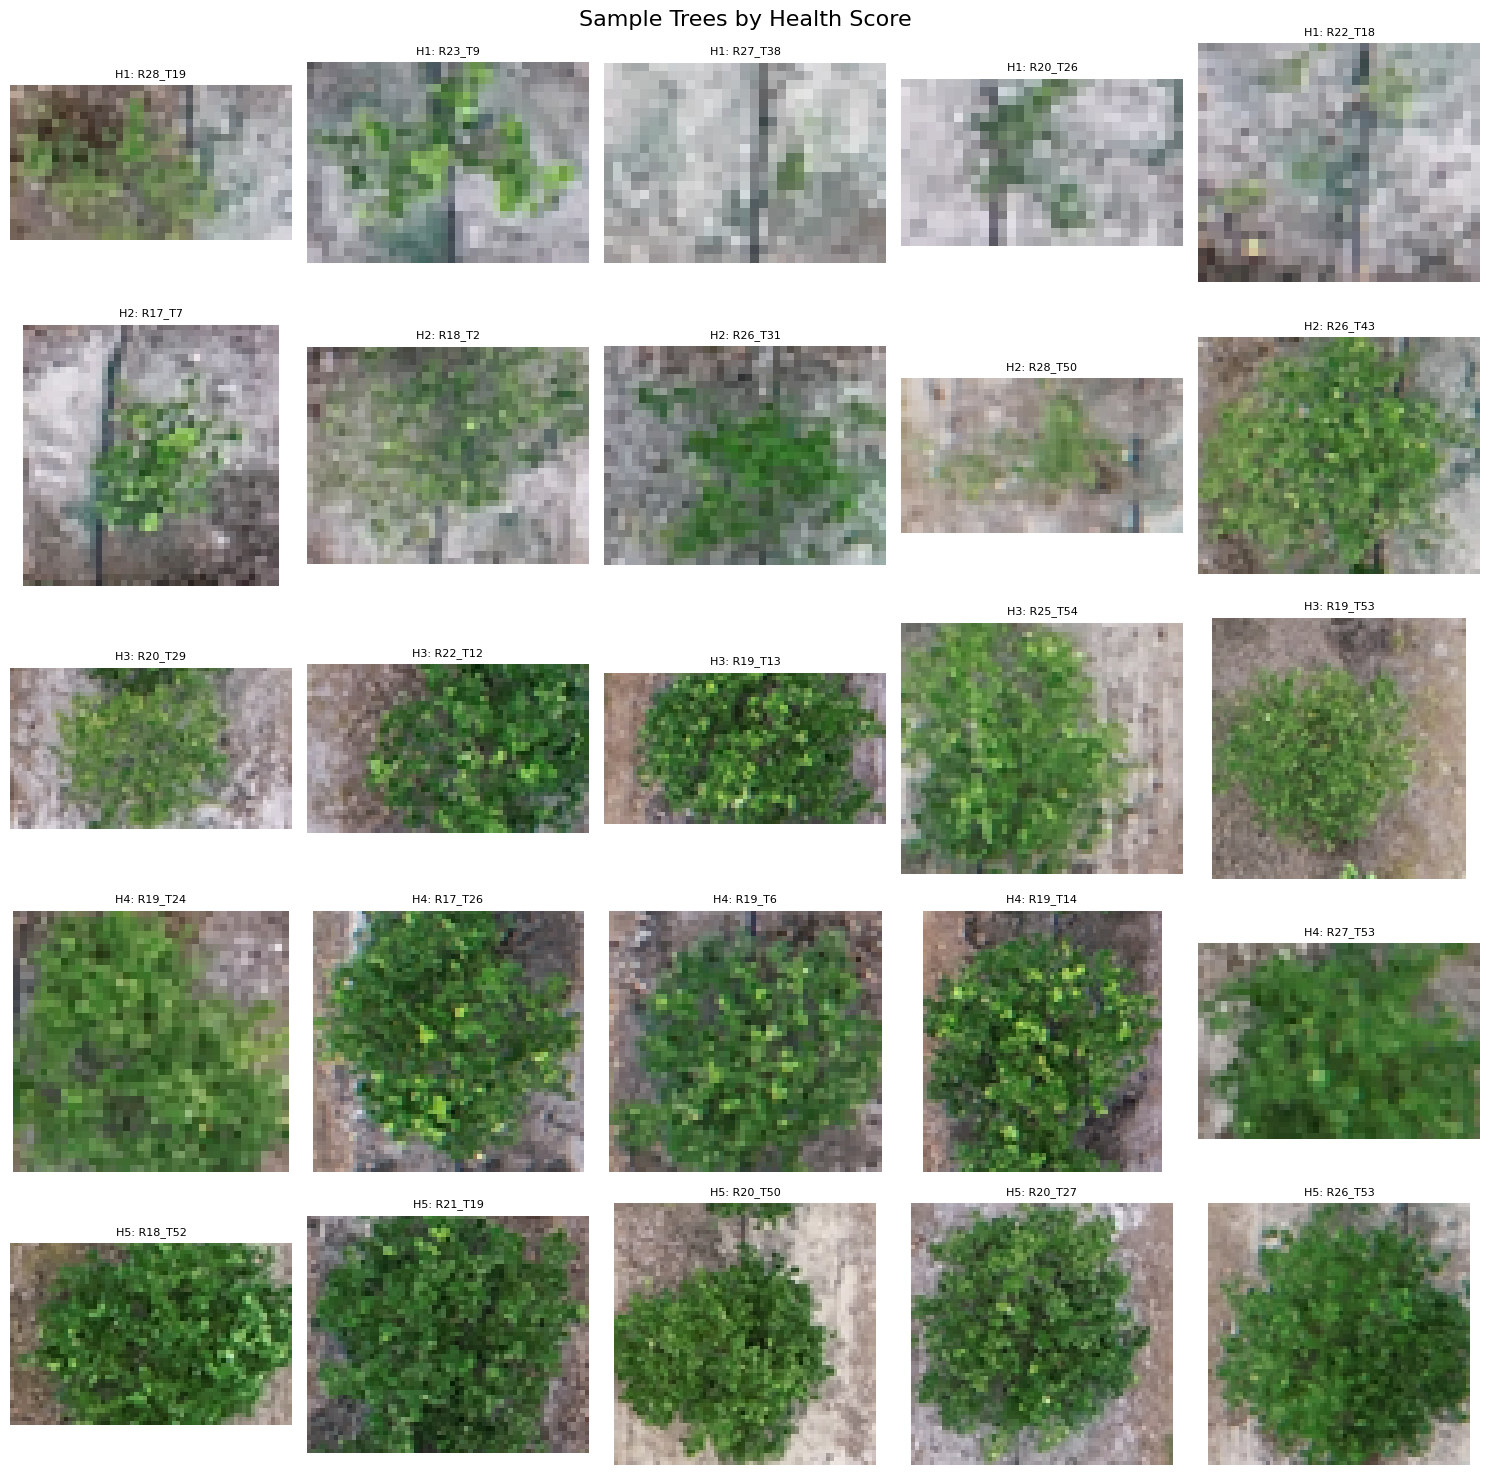

In [2]:
"""
YAML + YOLO ONLY - HANDLES RECTANGLES AND POLYGONS
Extracts tree crops from USDA dataset (Rows 17-28)
"""

import yaml
import re
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# ==================== CONFIGURATION ====================
# Update this path to your base directory
BASE_DIR = "HLB Health Classification"

# Paths (no need to edit)
YOLO_FOLDER = f"{BASE_DIR}/Tree Rows 17 to 28-Processed"
YAML_PATH = f"{YOLO_FOLDER}/data.yaml"
TRAIN_IMAGES = f"{YOLO_FOLDER}/train/images"
TRAIN_LABELS = f"{YOLO_FOLDER}/train/labels"

# ==================== EXTRACTION ====================
print("="*70)
print("EXTRACTING TREES - YAML MAPPING WITH POLYGON SUPPORT")
print("="*70)

# Load YAML
with open(YAML_PATH, 'r') as f:
    config = yaml.safe_load(f)
class_names = config['names']

print(f"Loaded {len(class_names)} classes from YAML")

# Get files
image_files = list(Path(TRAIN_IMAGES).glob('*.png')) + list(Path(TRAIN_IMAGES).glob('*.jpg'))
img_path = image_files[0]
label_path = Path(TRAIN_LABELS) / (img_path.stem + '.txt')

# Load image
img = Image.open(img_path).convert('RGB')
img_width, img_height = img.size

# Initialize lists
health_1 = []
health_2 = []
health_3 = []
health_4 = []
health_5 = []

# Process YOLO file
with open(label_path, 'r') as f:
    lines = f.readlines()

print(f"Processing {len(lines)} annotations")

h0_skipped = 0
extracted = 0

for line in lines:
    parts = line.strip().split()
    if len(parts) < 5:
        continue

    yolo_class_id = int(parts[0])
    yaml_index = yolo_class_id

    if yaml_index < 0 or yaml_index >= len(class_names):
        continue

    tree_name = class_names[yaml_index]

    match = re.match(r'R(\d+)_T(\d+)_H(\d+)', tree_name)
    if not match:
        continue

    row = int(match.group(1))
    tree = int(match.group(2))
    health = int(match.group(3))

    if health == 0:
        h0_skipped += 1
        continue

    if health < 1 or health > 5:
        continue

    # Handle both rectangle and polygon formats
    if len(parts) == 5:
        # RECTANGLE: class x_center y_center width height
        x_c = float(parts[1]) * img_width
        y_c = float(parts[2]) * img_height
        w = float(parts[3]) * img_width
        h = float(parts[4]) * img_height

        x1 = int(x_c - w/2)
        y1 = int(y_c - h/2)
        x2 = int(x_c + w/2)
        y2 = int(y_c + h/2)
    else:
        # POLYGON: class x1 y1 x2 y2 x3 y3...
        x_coords = []
        y_coords = []
        for i in range(1, len(parts), 2):
            if i+1 < len(parts):
                x_coords.append(float(parts[i]) * img_width)
                y_coords.append(float(parts[i+1]) * img_height)

        x1 = int(min(x_coords))
        y1 = int(min(y_coords))
        x2 = int(max(x_coords))
        y2 = int(max(y_coords))

    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(img_width, x2)
    y2 = min(img_height, y2)

    if (x2-x1) < 10 or (y2-y1) < 10:
        continue

    crop = img.crop((x1, y1, x2, y2))
    tree_id = f"R{row}_T{tree}"

    if health == 1:
        health_1.append((crop, tree_id))
    elif health == 2:
        health_2.append((crop, tree_id))
    elif health == 3:
        health_3.append((crop, tree_id))
    elif health == 4:
        health_4.append((crop, tree_id))
    elif health == 5:
        health_5.append((crop, tree_id))

    extracted += 1

print(f"\nExtraction complete!")
print(f"  Extracted: {extracted} trees")
print(f"  H0 skipped: {h0_skipped}")

# Display results
print("\n" + "="*70)
print("YOUR 5 LISTS HAVE BEEN CREATED")
print("="*70)

for health_list, h in [(health_1, 1), (health_2, 2), (health_3, 3), (health_4, 4), (health_5, 5)]:
    print(f"\nLIST {h} - HEALTH SCORE {h}")
    print(f"   Variable: health_{h}")
    print(f"   Count: {len(health_list)} trees")
    if health_list:
        print(f"   First 5 trees:")
        for i in range(min(5, len(health_list))):
            img_crop, tree_id = health_list[i]
            print(f"     [{i}] {tree_id} - {img_crop.size[0]}x{img_crop.size[1]}px")

# Summary
total = len(health_1) + len(health_2) + len(health_3) + len(health_4) + len(health_5)
print(f"\nSUMMARY")
print(f"Total: {total} trees")
if total > 0:
    for health_list, h in [(health_1, 1), (health_2, 2), (health_3, 3), (health_4, 4), (health_5, 5)]:
        print(f"  Health {h}: {len(health_list)} ({100*len(health_list)/total:.1f}%)")

# Visualization
if total > 0:
    fig, axes = plt.subplots(5, 5, figsize=(15, 15))
    fig.suptitle('Sample Trees by Health Score', fontsize=16)

    lists = [health_1, health_2, health_3, health_4, health_5]

    for row, (health_list, health_score) in enumerate(zip(lists, range(1, 6))):
        if health_list:
            num_samples = min(5, len(health_list))
            indices = np.random.choice(len(health_list), num_samples, replace=False) if len(health_list) > 5 else range(num_samples)

            for col, idx in enumerate(indices):
                img_crop, tree_id = health_list[idx]
                axes[row, col].imshow(img_crop)
                axes[row, col].set_title(f"H{health_score}: {tree_id}", fontsize=8)
                axes[row, col].axis('off')

            for col in range(num_samples, 5):
                axes[row, col].axis('off')
        else:
            for col in range(5):
                axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

Rows 5 to 16

Files in HLB Health Classification/Tree Rows 5 to 16-Processed:
  - Rows R5-R16_Valencia trial_labeled.png
  - Rows R5-R16_Valencia trial_labeled.txt
  - Rows R5-R16_Valencia trial_labeled_mapping.txt
  - _annotations.coco.json

Image: Rows R5-R16_Valencia trial_labeled.png
Annotations: Rows R5-R16_Valencia trial_labeled.txt
Mapping: Rows R5-R16_Valencia trial_labeled_mapping.txt

EXTRACTING TREES FROM VALENCIA R5-R16 DATASET

Loading class mapping...
Loaded 660 class mappings

Health distribution in classes:
  Health 0: 49 tree types
  Health 1: 5 tree types
  Health 2: 22 tree types
  Health 3: 326 tree types
  Health 4: 217 tree types
  Health 5: 41 tree types

Loading image...
Image size: 2916x4026

Processing annotations...
Found 660 annotations
  Processing annotation 601/660...

Extraction complete!
  Skipped 49 annotations (H0 or invalid boxes)

VALENCIA R5-R16 LISTS CREATED

VALENCIA LIST 1 - HEALTH SCORE 1
   Variable: valencia_health_1
   Count: 5 trees
   First 5 trees:
   

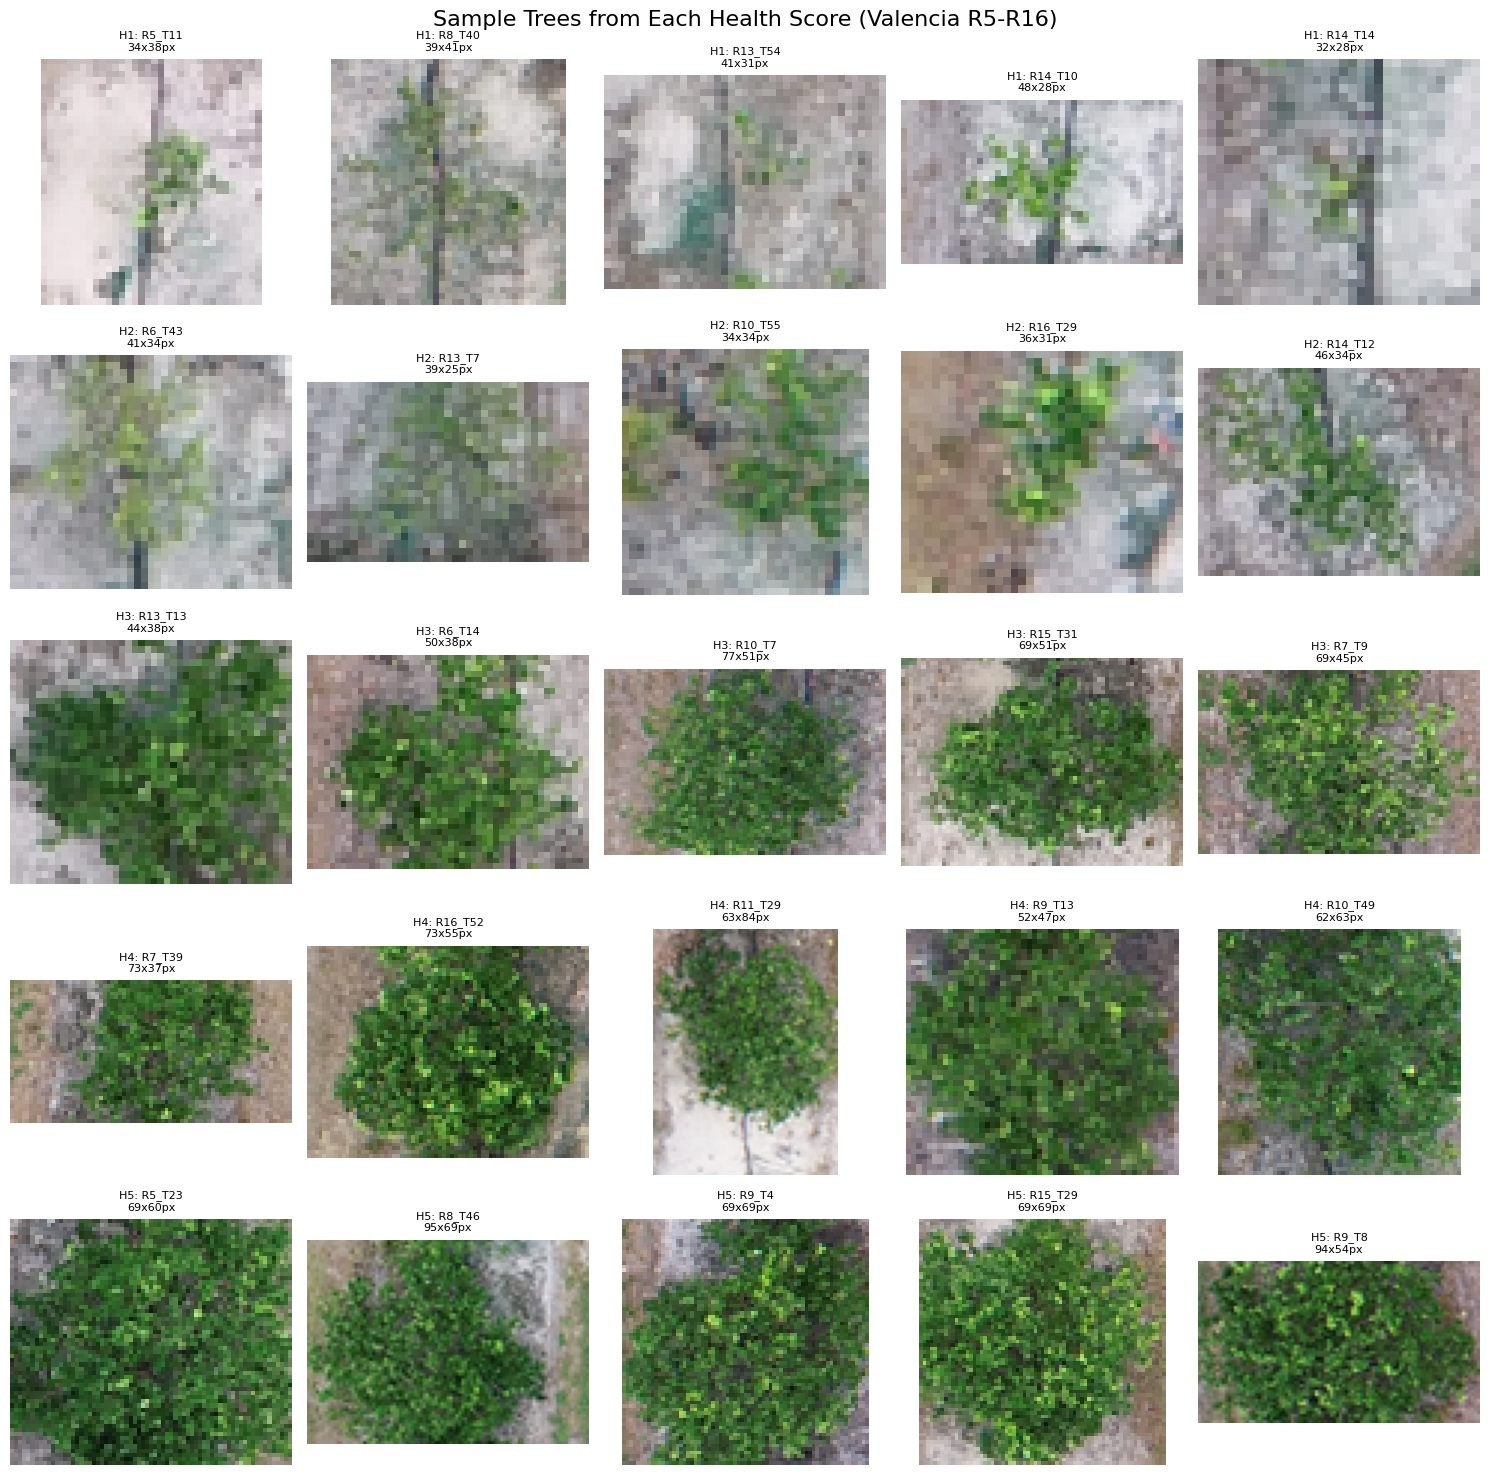


VALENCIA LISTS READY FOR CNN TRAINING

Your Valencia R5-R16 lists are now in these variables:
   valencia_health_1 - List of (image, tree_id) for health score 1
   valencia_health_2 - List of (image, tree_id) for health score 2
   valencia_health_3 - List of (image, tree_id) for health score 3
   valencia_health_4 - List of (image, tree_id) for health score 4
   valencia_health_5 - List of (image, tree_id) for health score 5

Each element is a tuple: (PIL_Image, 'R#_T#')
These can be combined with other datasets (health_1, health_2, etc.)


In [3]:
"""
Extracts tree crops from USDA dataset (Rows 5-16)
"""

import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import re

# ==================== CONFIGURATION ====================
# Update this path to your base directory
BASE_DIR = "HLB Health Classification"

# Paths (no need to edit)
BASE_FOLDER = f"{BASE_DIR}/Tree Rows 5 to 16-Processed"

# ==================== FILE DISCOVERY ====================
files = os.listdir(BASE_FOLDER)
print(f"Files in {BASE_FOLDER}:")
for f in files:
    print(f"  - {f}")

# Identify the files
image_file = None
txt_file = None
mapping_file = None

for f in files:
    if f.endswith(('.jpg', '.jpeg', '.png', '.JPG')):
        image_file = f
    elif f.endswith('_mapping.txt'):
        mapping_file = f
    elif f.endswith('.txt') and 'mapping' not in f:
        txt_file = f

print(f"\nImage: {image_file}")
print(f"Annotations: {txt_file}")
print(f"Mapping: {mapping_file}")

# Full paths
IMAGE_PATH = os.path.join(BASE_FOLDER, image_file) if image_file else None
YOLO_TXT = os.path.join(BASE_FOLDER, txt_file) if txt_file else None
MAPPING_FILE = os.path.join(BASE_FOLDER, mapping_file) if mapping_file else None

# ==================== FUNCTIONS ====================

def load_class_mapping(mapping_file):
    """Load the class ID to R#_T#_H# mapping"""
    mapping = {}
    with open(mapping_file, 'r') as f:
        for line in f:
            parts = line.strip().split(': ')
            if len(parts) == 2:
                class_id = int(parts[0])
                label = parts[1]
                mapping[class_id] = label
    return mapping

def parse_label(label):
    """Extract row, tree, health from 'R#_T#_H#' format"""
    pattern = r'R(\d+)_T(\d+)_H(\d+)'
    match = re.match(pattern, label)
    if match:
        return int(match.group(1)), int(match.group(2)), int(match.group(3))
    return None, None, None

def yolo_to_bbox(yolo_coords, img_width, img_height):
    """Convert YOLO normalized coords to pixel bbox"""
    x_center, y_center, width, height = yolo_coords

    x_center *= img_width
    y_center *= img_height
    width *= img_width
    height *= img_height

    x1 = int(x_center - width/2)
    y1 = int(y_center - height/2)
    x2 = int(x_center + width/2)
    y2 = int(y_center + height/2)

    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(img_width, x2)
    y2 = min(img_height, y2)

    return x1, y1, x2, y2

# ==================== MAIN PROCESSING ====================

print("\n" + "="*70)
print("EXTRACTING TREES FROM VALENCIA R5-R16 DATASET")
print("="*70)

# Load the class mapping
print(f"\nLoading class mapping...")
class_mapping = load_class_mapping(MAPPING_FILE)
print(f"Loaded {len(class_mapping)} class mappings")

# Check health distribution in mapping
health_dist = {0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0}
for label in class_mapping.values():
    _, _, health = parse_label(label)
    if health is not None:
        health_dist[health] += 1

print(f"\nHealth distribution in classes:")
for h in range(6):
    if health_dist[h] > 0:
        print(f"  Health {h}: {health_dist[h]} tree types")

# Load the image
print(f"\nLoading image...")
img = Image.open(IMAGE_PATH).convert('RGB')
img_width, img_height = img.size
print(f"Image size: {img_width}x{img_height}")

# Initialize the 5 lists for Valencia R5-R16
valencia_health_1 = []
valencia_health_2 = []
valencia_health_3 = []
valencia_health_4 = []
valencia_health_5 = []

# Process YOLO annotations
print(f"\nProcessing annotations...")
with open(YOLO_TXT, 'r') as f:
    lines = f.readlines()

print(f"Found {len(lines)} annotations")

# Process each annotation
trees_by_health = {1: 0, 2: 0, 3: 0, 4: 0, 5: 0}
skipped = 0

for line_idx, line in enumerate(lines):
    if line_idx % 100 == 0:
        print(f"  Processing annotation {line_idx+1}/{len(lines)}...", end='\r')

    parts = line.strip().split()
    if len(parts) != 5:
        continue

    # Parse YOLO format
    class_id = int(parts[0])
    x_center = float(parts[1])
    y_center = float(parts[2])
    width = float(parts[3])
    height = float(parts[4])

    # Get the label from mapping
    if class_id not in class_mapping:
        print(f"\nClass ID {class_id} not in mapping")
        continue

    label = class_mapping[class_id]
    row, tree, health = parse_label(label)

    # Skip if health is 0 or invalid
    if health is None or health < 1 or health > 5:
        skipped += 1
        continue

    # Convert to pixel coordinates
    x1, y1, x2, y2 = yolo_to_bbox(
        (x_center, y_center, width, height),
        img_width, img_height
    )

    # Skip if box is too small
    if (x2 - x1) < 10 or (y2 - y1) < 10:
        skipped += 1
        continue

    # Crop the tree
    tree_crop = img.crop((x1, y1, x2, y2))

    # Create tree ID without health
    tree_id = f"R{row}_T{tree}"

    # Add to appropriate Valencia-specific list
    if health == 1:
        valencia_health_1.append((tree_crop, tree_id))
        trees_by_health[1] += 1
    elif health == 2:
        valencia_health_2.append((tree_crop, tree_id))
        trees_by_health[2] += 1
    elif health == 3:
        valencia_health_3.append((tree_crop, tree_id))
        trees_by_health[3] += 1
    elif health == 4:
        valencia_health_4.append((tree_crop, tree_id))
        trees_by_health[4] += 1
    elif health == 5:
        valencia_health_5.append((tree_crop, tree_id))
        trees_by_health[5] += 1

print(f"\n\nExtraction complete!")
if skipped > 0:
    print(f"  Skipped {skipped} annotations (H0 or invalid boxes)")

# ==================== DISPLAY RESULTS ====================

print("\n" + "="*70)
print("VALENCIA R5-R16 LISTS CREATED")
print("="*70)

for health_list, h in [(valencia_health_1, 1), (valencia_health_2, 2), (valencia_health_3, 3), (valencia_health_4, 4), (valencia_health_5, 5)]:
    print(f"\nVALENCIA LIST {h} - HEALTH SCORE {h}")
    print(f"   Variable: valencia_health_{h}")
    print(f"   Count: {len(health_list)} trees")
    if len(health_list) > 0:
        print(f"   First 5 trees:")
        for i in range(min(5, len(health_list))):
            img_crop, tree_id = health_list[i]
            print(f"     [{i}] {tree_id} - {img_crop.size[0]}x{img_crop.size[1]}px")

# ==================== SUMMARY ====================

print("\n" + "="*70)
print("SUMMARY - VALENCIA R5-R16")
print("="*70)
total = len(valencia_health_1) + len(valencia_health_2) + len(valencia_health_3) + len(valencia_health_4) + len(valencia_health_5)
print(f"Total Valencia trees extracted: {total}")
if total > 0:
    print(f"  Health 1: {len(valencia_health_1)} trees ({100*len(valencia_health_1)/total:.1f}%)")
    print(f"  Health 2: {len(valencia_health_2)} trees ({100*len(valencia_health_2)/total:.1f}%)")
    print(f"  Health 3: {len(valencia_health_3)} trees ({100*len(valencia_health_3)/total:.1f}%)")
    print(f"  Health 4: {len(valencia_health_4)} trees ({100*len(valencia_health_4)/total:.1f}%)")
    print(f"  Health 5: {len(valencia_health_5)} trees ({100*len(valencia_health_5)/total:.1f}%)")

# ==================== VISUALIZATION ====================

if total > 0:
    print("\nDisplaying sample trees from each health score...")

    fig, axes = plt.subplots(5, 5, figsize=(15, 15))
    fig.suptitle('Sample Trees from Each Health Score (Valencia R5-R16)', fontsize=16)

    lists = [valencia_health_1, valencia_health_2, valencia_health_3, valencia_health_4, valencia_health_5]

    for row, (health_list, health_score) in enumerate(zip(lists, range(1, 6))):
        if len(health_list) > 0:
            num_samples = min(5, len(health_list))
            if len(health_list) > 5:
                sample_indices = np.random.choice(len(health_list), num_samples, replace=False)
            else:
                sample_indices = range(num_samples)

            for col, idx in enumerate(sample_indices):
                img_crop, tree_id = health_list[idx]
                ax = axes[row, col]
                ax.imshow(img_crop)
                ax.set_title(f"H{health_score}: {tree_id}\n{img_crop.size[0]}x{img_crop.size[1]}px", fontsize=8)
                ax.axis('off')

            for col in range(num_samples, 5):
                axes[row, col].axis('off')
        else:
            for col in range(5):
                axes[row, col].axis('off')
            axes[row, 0].text(0.5, 0.5, f"No trees for Health {health_score}",
                            ha='center', va='center', fontsize=12)

    plt.tight_layout()
    plt.show()
else:
    print("\nNo trees extracted! Check your data paths and format.")

# ==================== READY FOR CNN ====================

print("\n" + "="*70)
print("VALENCIA LISTS READY FOR CNN TRAINING")
print("="*70)
print("\nYour Valencia R5-R16 lists are now in these variables:")
print("   valencia_health_1 - List of (image, tree_id) for health score 1")
print("   valencia_health_2 - List of (image, tree_id) for health score 2")
print("   valencia_health_3 - List of (image, tree_id) for health score 3")
print("   valencia_health_4 - List of (image, tree_id) for health score 4")
print("   valencia_health_5 - List of (image, tree_id) for health score 5")
print("\nEach element is a tuple: (PIL_Image, 'R#_T#')")
print("These can be combined with other datasets (health_1, health_2, etc.)")

## Combining the Two into 1 Datset and Perfroming Split

In [4]:
# 3-class data split
# Poor (H1+H2), Moderate (H3), Good (H4+H5)

import random
import numpy as np
from PIL import Image

print("="*70)
print("3-CLASS DATA SPLIT")
print("Poor (H1+H2) | Moderate (H3) | Good (H4+H5)")
print("="*70)

# ==================== STEP 1: COMBINE DATASETS ====================
print("\n[1] Combining datasets...")

all_h1 = valencia_health_1 + health_1
all_h2 = valencia_health_2 + health_2
all_h3 = valencia_health_3 + health_3
all_h4 = valencia_health_4 + health_4
all_h5 = valencia_health_5 + health_5

print(f"  H1: {len(all_h1)}")
print(f"  H2: {len(all_h2)}")
print(f"  H3: {len(all_h3)}")
print(f"  H4: {len(all_h4)}")
print(f"  H5: {len(all_h5)}")

# ==================== STEP 2: CREATE 3 CLASSES ====================
print("\n[2] Creating 3 classes...")

all_poor = all_h1 + all_h2      # Poor (H1+H2)
all_moderate = all_h3           # Moderate (H3)
all_good = all_h4 + all_h5      # Good (H4+H5)

print(f"\n3-class distribution (BEFORE split):")
print(f"  Poor (H1+H2):     {len(all_poor)}")
print(f"  Moderate (H3):    {len(all_moderate)}")
print(f"  Good (H4+H5):     {len(all_good)}")
print(f"  Total:            {len(all_poor) + len(all_moderate) + len(all_good)}")

# ==================== STEP 3: SPLIT FIRST (70/10/20) ====================
print("\n[3] Splitting into train/val/test (70/10/20)...")

random.seed(42)

def split_list(data_list, train_ratio=0.7, val_ratio=0.1):
    shuffled = data_list.copy()
    random.shuffle(shuffled)
    n = len(shuffled)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))
    return shuffled[:train_end], shuffled[train_end:val_end], shuffled[val_end:]

train_poor, val_poor, test_poor = split_list(all_poor)
train_moderate, val_moderate, test_moderate = split_list(all_moderate)
train_good, val_good, test_good = split_list(all_good)

print(f"\nSplit results (BEFORE augmentation):")
print(f"  Poor:     train={len(train_poor)}, val={len(val_poor)}, test={len(test_poor)}")
print(f"  Moderate: train={len(train_moderate)}, val={len(val_moderate)}, test={len(test_moderate)}")
print(f"  Good:     train={len(train_good)}, val={len(val_good)}, test={len(test_good)}")

# ==================== STEP 4: AUGMENT TRAINING ONLY ====================
print("\n[4] Augmenting TRAINING data only...")

def rotate_with_black(img, angle):
    """Rotate image with black background"""
    img_rgba = img.convert('RGBA')
    rotated = img_rgba.rotate(angle, expand=True, fillcolor=(0, 0, 0, 255))
    rotated_rgb = Image.new('RGB', rotated.size, (0, 0, 0))
    rotated_rgb.paste(rotated, mask=rotated.split()[3])
    return rotated_rgb

def augment_list(data_list, rotations):
    """Add rotated copies to list"""
    augmented = []
    for img, tree_id in data_list:
        for angle in rotations:
            rotated = rotate_with_black(img, angle)
            augmented.append((rotated, tree_id))
    return augmented

# Rotation strategies
rotations_15deg = [15, 30, 45, 60, 75, 90, 105, 120, 135, 150, 165, 180,
                   195, 210, 225, 240, 255, 270, 285, 300, 315, 330, 345]  # 23 rotations
rotations_90deg = [90, 180, 270]  # 3 rotations

# Poor: 15° increments (23 rotations) - minority class
print("  Augmenting Poor (15° increments, 23 rotations)...")
aug_poor = augment_list(train_poor, rotations_15deg)
train_poor_orig = len(train_poor)
train_poor = train_poor + aug_poor

# Moderate: 90° increments (3 rotations) - majority class
print("  Augmenting Moderate (90° increments, 3 rotations)...")
aug_moderate = augment_list(train_moderate, rotations_90deg)
train_moderate_orig = len(train_moderate)
train_moderate = train_moderate + aug_moderate

# Good: 90° increments (3 rotations) - combined H4+H5
print("  Augmenting Good (90° increments, 3 rotations)...")
aug_good = augment_list(train_good, rotations_90deg)
train_good_orig = len(train_good)
train_good = train_good + aug_good

print(f"\nTraining set AFTER augmentation:")
print(f"  Poor:     {len(train_poor)} (orig {train_poor_orig} × 24)")
print(f"  Moderate: {len(train_moderate)} (orig {train_moderate_orig} × 4)")
print(f"  Good:     {len(train_good)} (orig {train_good_orig} × 4)")

# ==================== STEP 5: CREATE FINAL DATASETS ====================
print("\n[5] Creating final datasets...")

train_data = []
for img, tree_id in train_poor:
    train_data.append((img, tree_id, 0))       # Poor = 0
for img, tree_id in train_moderate:
    train_data.append((img, tree_id, 1))       # Moderate = 1
for img, tree_id in train_good:
    train_data.append((img, tree_id, 2))       # Good = 2

val_data = []
for img, tree_id in val_poor:
    val_data.append((img, tree_id, 0))
for img, tree_id in val_moderate:
    val_data.append((img, tree_id, 1))
for img, tree_id in val_good:
    val_data.append((img, tree_id, 2))

test_data = []
for img, tree_id in test_poor:
    test_data.append((img, tree_id, 0))
for img, tree_id in test_moderate:
    test_data.append((img, tree_id, 1))
for img, tree_id in test_good:
    test_data.append((img, tree_id, 2))

# ==================== SUMMARY ====================
print("\n" + "="*70)
print("✅ FINAL 3-CLASS DATASETS")
print("="*70)
print(f"\n  Train: {len(train_data)} samples (augmented)")
print(f"  Val:   {len(val_data)} samples (original only)")
print(f"  Test:  {len(test_data)} samples (original only)")

print(f"\nTraining class distribution:")
print(f"  Poor:     {len(train_poor)}")
print(f"  Moderate: {len(train_moderate)}")
print(f"  Good:     {len(train_good)}")

print(f"\nTest set breakdown:")
print(f"  Poor:     {len(test_poor)}")
print(f"  Moderate: {len(test_moderate)}")
print(f"  Good:     {len(test_good)}")

print(f"\nClass mapping:")
print(f"  0 = Poor (H1+H2)")
print(f"  1 = Moderate (H3)")
print(f"  2 = Good (H4+H5)")

print("\n✅ Ready for 3-class training!")

3-CLASS DATA SPLIT
Poor (H1+H2) | Moderate (H3) | Good (H4+H5)

[1] Combining datasets...
  H1: 13
  H2: 74
  H3: 665
  H4: 427
  H5: 55

[2] Creating 3 classes...

3-class distribution (BEFORE split):
  Poor (H1+H2):     87
  Moderate (H3):    665
  Good (H4+H5):     482
  Total:            1234

[3] Splitting into train/val/test (70/10/20)...

Split results (BEFORE augmentation):
  Poor:     train=60, val=9, test=18
  Moderate: train=465, val=67, test=133
  Good:     train=337, val=48, test=97

[4] Augmenting TRAINING data only...
  Augmenting Poor (15° increments, 23 rotations)...
  Augmenting Moderate (90° increments, 3 rotations)...
  Augmenting Good (90° increments, 3 rotations)...

Training set AFTER augmentation:
  Poor:     1440 (orig 60 × 24)
  Moderate: 1860 (orig 465 × 4)
  Good:     1348 (orig 337 × 4)

[5] Creating final datasets...

✅ FINAL 3-CLASS DATASETS

  Train: 4648 samples (augmented)
  Val:   124 samples (original only)
  Test:  248 samples (original only)

Train

# Model Test 

## Training Notes
BCE pos_weight values tuned via grid search:
- Poor specialist: 3
- Moderate specialist: 0.5
- Good specialist: 5.3

Inference uses argmax (no additional weighting).

## Test Set Script

In [9]:
import os, random
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
from sklearn.metrics import confusion_matrix, accuracy_score

# ==================== CONFIGURATION ====================
# Update this path to your base directory
BASE_DIR = "HLB Health Classification"

# Paths (no need to edit)
CHECKPOINT_PATH = f"{BASE_DIR}/swin_3specialists_FINAL.pth"

# Model settings
SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 8
NUM_WORKERS = 0
MODEL_NAME = "swin_tiny_patch4_window7_224"
CLASS_NAMES = ['Poor', 'Moderate', 'Good']

# Training loss weights (BCE pos_weight, tuned via grid search)
# Poor specialist: 3.0
# Moderate specialist: 0.5
# Good specialist: 5.3
# Inference uses argmax (no additional weighting)

# ==================== UTILS ====================
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

class ListDataset(Dataset):
    def __init__(self, data_list, img_size=224):
        self.data = data_list
        self.tfms = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img, tree_id, label = self.data[idx]
        return self.tfms(img), label

# ==================== TTA ====================
def apply_8view_tta(model, x, device):
    model.eval()
    logits_list = []
    with torch.no_grad():
        for rot in [0, 1, 2, 3]:
            x_rot = torch.rot90(x, rot, [2, 3])
            logits_list.append(model(x_rot))
            logits_list.append(model(torch.flip(x_rot, dims=[3])))
    return torch.stack(logits_list).mean(dim=0)

# ==================== INFERENCE ====================
def get_test_probs(models, loader_te, device):
    """Get test probabilities from all 3 specialists with TTA"""
    test_probs = []
    total_batches = len(loader_te)
    
    for i in range(3):
        print(f"\n  Specialist {i+1}/3 ({CLASS_NAMES[i]})...")
        models[i].eval()
        probs = []
        with torch.no_grad():
            for batch_idx, (x, _) in enumerate(loader_te):
                x = x.to(device)
                logits = apply_8view_tta(models[i], x, device).squeeze(-1)
                p = torch.sigmoid(logits)
                probs.append(p.cpu().numpy())
                
                # Progress update every 5 batches
                if (batch_idx + 1) % 5 == 0 or (batch_idx + 1) == total_batches:
                    print(f"    Batch {batch_idx+1}/{total_batches}", end='\r')
        
        print(f"    Batch {total_batches}/{total_batches} - Done")
        test_probs.append(np.concatenate(probs))
    
    return np.stack(test_probs, axis=1)

def print_results(test_labels, preds):
    """Print accuracy, per-class, confusion matrix"""
    acc = accuracy_score(test_labels, preds)
    cm = confusion_matrix(test_labels, preds, labels=range(3))
    pc = [100*cm[i,i]/max(1,cm[i].sum()) for i in range(3)]

    print(f"\nAccuracy: {acc:.3f} ({int(acc*len(test_labels))}/{len(test_labels)})")
    print(f"\nPer-class:")
    for i, c in enumerate(CLASS_NAMES):
        print(f"  {c}: {cm[i,i]}/{cm[i].sum()} ({pc[i]:.1f}%)")

    print(f"\nConfusion Matrix:")
    print(f"           Poor  Mod   Good")
    for i, c in enumerate(CLASS_NAMES):
        print(f"  {c:<8} {cm[i,0]:3d}   {cm[i,1]:3d}   {cm[i,2]:3d}")

    within_1 = sum(1 for t, p in zip(test_labels, preds) if abs(t - p) <= 1)
    print(f"\nWithin ±1: {within_1}/{len(test_labels)} ({100*within_1/len(test_labels):.1f}%)")

# ==================== MAIN ====================
def main():
    print("="*60)
    print("HEALTH CLASSIFICATION - EVALUATION")
    print("="*60)

    set_seed()
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Device: {device}")

    # Clear GPU
    if device == "cuda":
        torch.cuda.empty_cache()
        print("GPU cache cleared")

    # Load checkpoint
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
    saved_states = checkpoint["specialists"]
    print(f"Loaded: {CHECKPOINT_PATH}")

    # Load models
    models = []
    for i in range(3):
        model = timm.create_model(MODEL_NAME, pretrained=False, num_classes=1).to(device)
        model.load_state_dict(saved_states[i])
        model.eval()
        models.append(model)
    print("Models loaded successfully")

    # Create test loader
    # NOTE: test_data should come from your data loading/splitting code
    ds_te = ListDataset(test_data, IMG_SIZE)
    loader_te = DataLoader(ds_te, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    test_labels = np.array([label for _, _, label in test_data])

    print(f"Test samples: {len(test_data)}")
    print(f"Batch size: {BATCH_SIZE}")
    print(f"Total batches: {len(loader_te)}")

    # Run inference
    print("\nRunning inference with 8-view TTA...")
    test_probs = get_test_probs(models, loader_te, device)
    preds = test_probs.argmax(axis=1)

    # Print results
    print_results(test_labels, preds)

if __name__ == "__main__":
    main()

HEALTH CLASSIFICATION - EVALUATION
Device: cuda
GPU cache cleared
Loaded: HLB Health Classification/swin_3specialists_FINAL.pth
Models loaded successfully
Test samples: 248
Batch size: 8
Total batches: 31

Running inference with 8-view TTA...

  Specialist 1/3 (Poor)...
    Batch 31/31 - Done

  Specialist 2/3 (Moderate)...
    Batch 31/31 - Done

  Specialist 3/3 (Good)...
    Batch 31/31 - Done

Accuracy: 0.810 (201/248)

Per-class:
  Poor: 15/18 (83.3%)
  Moderate: 111/133 (83.5%)
  Good: 75/97 (77.3%)

Confusion Matrix:
           Poor  Mod   Good
  Poor      15     3     0
  Moderate   2   111    20
  Good       0    22    75

Within ±1: 248/248 (100.0%)


## Single Tree Inference Example

Loads the trained model and predicts the health class for a single tree from the test set.

In [12]:
import torch
import timm
from torchvision import transforms

# ==================== CONFIGURATION ====================
# Update this path to your base directory
BASE_DIR = "HLB Health Classification"

# Paths (no need to edit)
CHECKPOINT_PATH = f"{BASE_DIR}/swin_3specialists_FINAL.pth"

# Model settings
IMG_SIZE = 224
MODEL_NAME = "swin_tiny_patch4_window7_224"
CLASS_NAMES = ['Poor', 'Moderate', 'Good']

# ==================== LOAD MODELS ====================
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
saved_states = checkpoint["specialists"]

models = []
for i in range(3):
    model = timm.create_model(MODEL_NAME, pretrained=False, num_classes=1).to(device)
    model.load_state_dict(saved_states[i])
    model.eval()
    models.append(model)

print("Models loaded")

# ==================== SINGLE TREE INFERENCE ====================
# Pick a single tree from test_data (e.g., index 0)
# test_data format: [(PIL_Image, tree_id, label), ...]
sample_idx = 0
img, tree_id, true_label = test_data[sample_idx]

# Preprocess
tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
])
x = tfms(img).unsqueeze(0).to(device)

# Predict
with torch.no_grad():
    probs = [torch.sigmoid(model(x)).item() for model in models]

pred = probs.index(max(probs))

# Results
print(f"\nTree ID: {tree_id}")
print(f"True Label: {CLASS_NAMES[true_label]}")
print(f"Prediction: {CLASS_NAMES[pred]}")
print(f"Probabilities: Poor={probs[0]:.3f}, Moderate={probs[1]:.3f}, Good={probs[2]:.3f}")

Device: cuda
Models loaded

Tree ID: R28_T2
True Label: Poor
Prediction: Poor
Probabilities: Poor=0.926, Moderate=0.926, Good=0.000
